<a href="https://colab.research.google.com/github/Sumit05-Y/EDA-DATASCIENCE/blob/main/Nlic(LINEAR).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             r2_score, classification_report,
                             confusion_matrix)

In [ ]:
nlic=pd.read_csv("NLIC_CLEAN.csv")
nlic["Date"] = pd.to_datetime(nlic["Date"])
nlic.head()
nlic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223 entries, 0 to 222
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            223 non-null    datetime64[ns]
 1   Open            223 non-null    float64       
 2   High            223 non-null    float64       
 3   Low             223 non-null    float64       
 4   Close           223 non-null    float64       
 5   Percent Change  223 non-null    float64       
 6   Volume          125 non-null    float64       
 7   Daily Return    222 non-null    float64       
 8   MA20            204 non-null    float64       
 9   MA50            174 non-null    float64       
 10  Volatility      203 non-null    float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 19.3 KB


In [ ]:
nlic["Next_Close"] = nlic["Close"].shift(-1)
nlic["Direction"]=(nlic["Next_Close"]>nlic["Close"]).astype(int)

In [ ]:
features=["Open", "High", "Low", "Volume", "MA20", "MA50"]
data = nlic.dropna(subset=features + ["Next_Close"]).reset_index(drop=True)
print(f"Usable rows: {len(data)}(out of {len(nlic)})")

Usable rows: 124(out of 223)


In [ ]:
X= data[features]
y_reg = data["Next_Close"]
X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, shuffle=False
                                                    )
scaler = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)


LinearRegression()

In [ ]:
y_pred = lr_model.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.2f} NPR")
print(f"MAE: {mae:.2f} NPR")
print(f"R2: {r2:.3f}")

RMSE: 9.52 NPR
MAE: 8.40 NPR
R2: 0.184


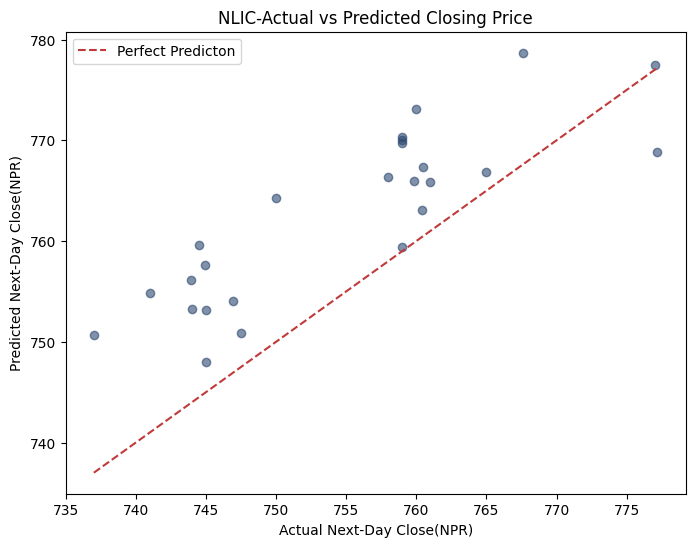

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha = 0.6, color="#2C4870")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="#C13A3A",linestyle="--", label="Perfect Predicton")
plt.xlabel("Actual Next-Day Close(NPR)")
plt.ylabel("Predicted Next-Day Close(NPR)")
plt.title("NLIC-Actual vs Predicted Closing Price")
plt.legend()
plt.show()


In [ ]:
days = int(input("Enter number of days ahead to predict: "))

current_features = nlic[features].iloc[-1].copy()
last_date = pd.to_datetime(nlic["Date"].iloc[-1])

for i in range(1, days + 1):
    input_df = pd.DataFrame([current_features])
    scaled_features = scaler.transform(input_df)
    predicted_price = lr_model.predict(scaled_features)[0]
    predicted_date = last_date + pd.Timedelta(days=i)

    print(f"Date: {predicted_date.strftime('%Y-%m-%d')} | Predicted Close: {predicted_price:.2f} NPR")


    for col in ["Open", "High", "Low", "Close"]:
        if col in current_features:
            current_features[col] = predicted_price

Enter number of days ahead to predict: 3
Date: 2026-07-08 | Predicted Close: 755.58 NPR
Date: 2026-07-09 | Predicted Close: 765.21 NPR
Date: 2026-07-10 | Predicted Close: 773.84 NPR
